##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


# Importing

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import cv2
import random
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from typing import List, Tuple
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical, plot_model

# Configuration

In [5]:
student_name = "RaghadAlamoudi"  # Replace with your actual name
dataset_directory = "/Users/raghadhome/Downloads/action_youtube_naudio"  # Change to your extracted UCF11 folder
chosen_classes = ["basketball", "biking", "tennis_swing"]  # Adjust to exact folder names in your dataset

image_height = 64
image_width = 64
channels = 3

frames_per_video = 12
max_videos_per_class = None  # Use None to keep all videos
test_size = 0.2
random_seed = 23
batch_size = 16
epochs = 20

np.random.seed(random_seed)
random.seed(random_seed)
tf.random.set_seed(random_seed)

# Utilities

In [6]:
def find_available_classes(dataset_root: str) -> List[str]:
    root = Path(dataset_root)
    if not root.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_root}")
    return sorted([item.name for item in root.iterdir() if item.is_dir()])


def validate_chosen_classes(dataset_root: str, class_names: List[str]) -> None:
    available = set(find_available_classes(dataset_root))
    missing = [class_name for class_name in class_names if class_name not in available]
    if missing:
        raise ValueError(
            f"These classes were not found in '{dataset_root}': {missing}\n"
            f"Available classes: {sorted(available)}"
        )


def list_videos_for_class(dataset_root: str, class_name: str) -> List[str]:
    class_path = Path(dataset_root) / class_name
    if not class_path.exists():
        return []

    video_paths: List[str] = []
    valid_suffixes = {".avi", ".mp4", ".mov", ".mkv", ".mpeg", ".mpg"}

    for group_dir in class_path.iterdir():
        if not group_dir.is_dir():
            continue
        for file_path in group_dir.iterdir():
            if file_path.is_file() and file_path.suffix.lower() in valid_suffixes:
                video_paths.append(str(file_path))

    return sorted(video_paths)


def sample_frame_indices(total_frames: int, num_samples: int) -> np.ndarray:
    if total_frames <= 0:
        return np.array([], dtype=int)
    if total_frames < num_samples:
        return np.linspace(0, total_frames - 1, total_frames, dtype=int)
    return np.linspace(0, total_frames - 1, num_samples, dtype=int)


def extract_sampled_frames(
    video_path: str,
    target_size: Tuple[int, int],
    num_samples: int,
) -> List[np.ndarray]:
    frames: List[np.ndarray] = []
    video_reader = cv2.VideoCapture(video_path)

    if not video_reader.isOpened():
        return frames

    total_frames = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = sample_frame_indices(total_frames, num_samples)

    for frame_index in frame_indices:
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
        success, frame = video_reader.read()
        if not success or frame is None:
            continue

        frame_resized = cv2.resize(frame, target_size)
        frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
        frame_normalized = frame_rgb.astype(np.float32) / 255.0
        frames.append(frame_normalized)

    video_reader.release()
    return frames


def create_dataset(
    dataset_root: str,
    class_names: List[str],
    target_size: Tuple[int, int],
    num_samples_per_video: int,
    max_videos_each_class: int | None = None,
) -> Tuple[np.ndarray, np.ndarray]:
    features: List[np.ndarray] = []
    labels: List[int] = []

    for class_index, class_name in enumerate(class_names):
        video_paths = list_videos_for_class(dataset_root, class_name)

        if not video_paths:
            print(f"Warning: no videos found for class '{class_name}'")
            continue

        if max_videos_each_class is not None:
            video_paths = video_paths[:max_videos_each_class]

        print(f"Processing class '{class_name}' with {len(video_paths)} videos")

        for video_path in video_paths:
            sampled_frames = extract_sampled_frames(
                video_path=video_path,
                target_size=target_size,
                num_samples=num_samples_per_video,
            )

            for frame in sampled_frames:
                features.append(frame)
                labels.append(class_index)

    if not features:
        raise ValueError("No training data was created. Check dataset path and class names.")

    x = np.asarray(features, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int32)
    return x, y


def show_random_samples(x: np.ndarray, y: np.ndarray, class_names: List[str], num_samples: int = 9) -> None:
    plt.figure(figsize=(12, 12))
    selected_indices = np.random.choice(len(x), size=min(num_samples, len(x)), replace=False)

    for plot_index, sample_index in enumerate(selected_indices, start=1):
        plt.subplot(3, 3, plot_index)
        plt.imshow(x[sample_index])
        plt.title(class_names[int(y[sample_index])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Model

In [7]:
def build_model(input_shape: Tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    model = Sequential(
        [
            Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
            MaxPooling2D((2, 2)),

            Conv2D(64, (3, 3), activation="relu", padding="same"),
            MaxPooling2D((2, 2)),

            Conv2D(128, (3, 3), activation="relu", padding="same"),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            GlobalAveragePooling2D(),
            Dense(128, activation="relu"),
            Dropout(0.3),
            Dense(num_classes, activation="softmax"),
        ]
    )
    return model


def plot_training_history(history: tf.keras.callbacks.History) -> None:
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, accuracy, label="Train Accuracy")
    plt.plot(epochs_range, val_accuracy, label="Val Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Validation

In [8]:
def predict_video_average(
    model: tf.keras.Model,
    video_path: str,
    class_names: List[str],
    target_size: Tuple[int, int],
    num_samples: int = 20,
) -> Tuple[str, float, np.ndarray]:
    sampled_frames = extract_sampled_frames(
        video_path=video_path,
        target_size=target_size,
        num_samples=num_samples,
    )

    if not sampled_frames:
        raise ValueError(f"Could not read frames from video: {video_path}")

    frame_batch = np.asarray(sampled_frames, dtype=np.float32)
    probabilities = model.predict(frame_batch, verbose=0)
    average_probabilities = probabilities.mean(axis=0)

    predicted_index = int(np.argmax(average_probabilities))
    predicted_class = class_names[predicted_index]
    predicted_confidence = float(average_probabilities[predicted_index])

    return predicted_class, predicted_confidence, average_probabilities


def validate_external_videos(
    model: tf.keras.Model,
    class_names: List[str],
    external_video_paths: List[str],
    target_size: Tuple[int, int],
    num_samples: int = 20,
) -> None:
    print("\nExternal Video Validation")
    print("-" * 50)

    for video_path in external_video_paths:
        predicted_class, confidence, probs = predict_video_average(
            model=model,
            video_path=video_path,
            class_names=class_names,
            target_size=target_size,
            num_samples=num_samples,
        )

        print(f"Video: {video_path}")
        print(f"Predicted class: {predicted_class}")
        print(f"Confidence: {confidence:.4f}")
        print("Class probabilities:")
        for class_name, prob in zip(class_names, probs):
            print(f"  {class_name:<20} {prob:.4f}")
        print("-" * 50)

# Main pipeline

Processing class 'basketball' with 141 videos
Processing class 'biking' with 145 videos
Processing class 'tennis_swing' with 167 videos
Features shape: (5424, 64, 64, 3)
Labels shape: (5424,)


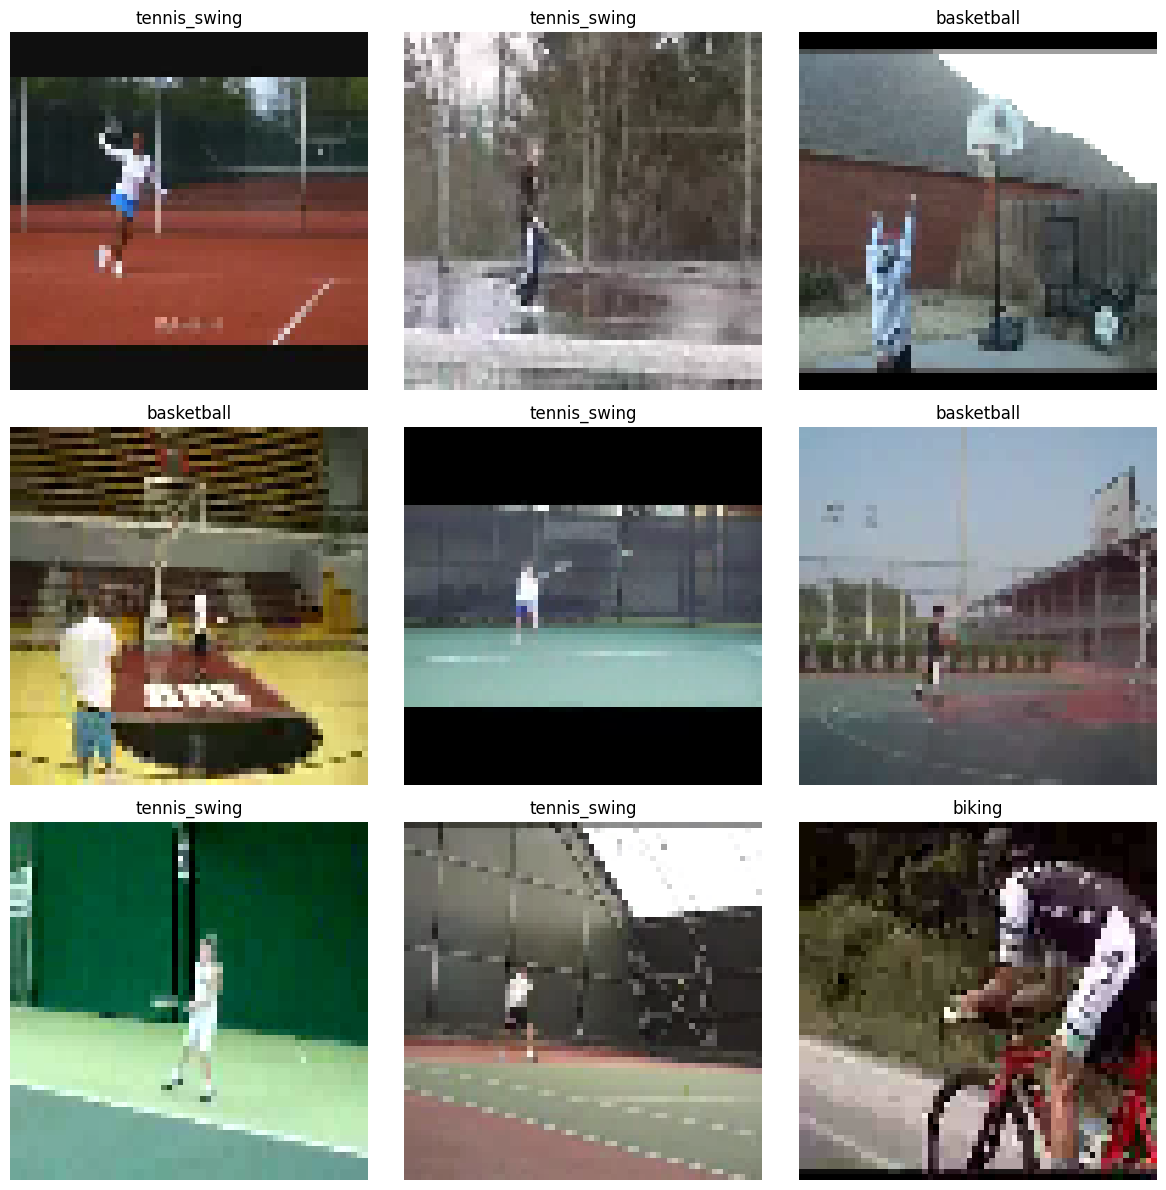

x_train: (4339, 64, 64, 3), y_train: (4339, 3)
x_test:  (1085, 64, 64, 3), y_test:  (1085, 3)


/opt/anaconda3/envs/cv_lab/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,659 (432.26 KB)

 Trainable params: 110,403 (431.26 KB)

 Non-trainable params: 256 (1.00 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7113 - loss: 0.6697 - val_accuracy: 0.6406 - val_loss: 0.7901
Epoch 2/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8825 - loss: 0.2984 - val_accuracy: 0.6429 - val_loss: 1.1122
Epoch 3/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9375 - loss: 0.1800 - val_accuracy: 0.8364 - val_loss: 0.3513
Epoch 4/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9551 - loss: 0.1206 - val_accuracy: 0.9435 - val_loss: 0.1533
Epoch 5/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9672 - loss: 0.0863 - val_accuracy: 0.8975 - val_loss: 0.2564
Epoch 6/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9804 - loss: 0.0562 - val_accuracy: 0.8618 - val_loss: 0.4588
Epoch 7/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9772 - loss: 0.0597 - val_accuracy: 0.9585 - val_loss: 0.1069
Epoch 8/20
217/217 ━━━━━━━

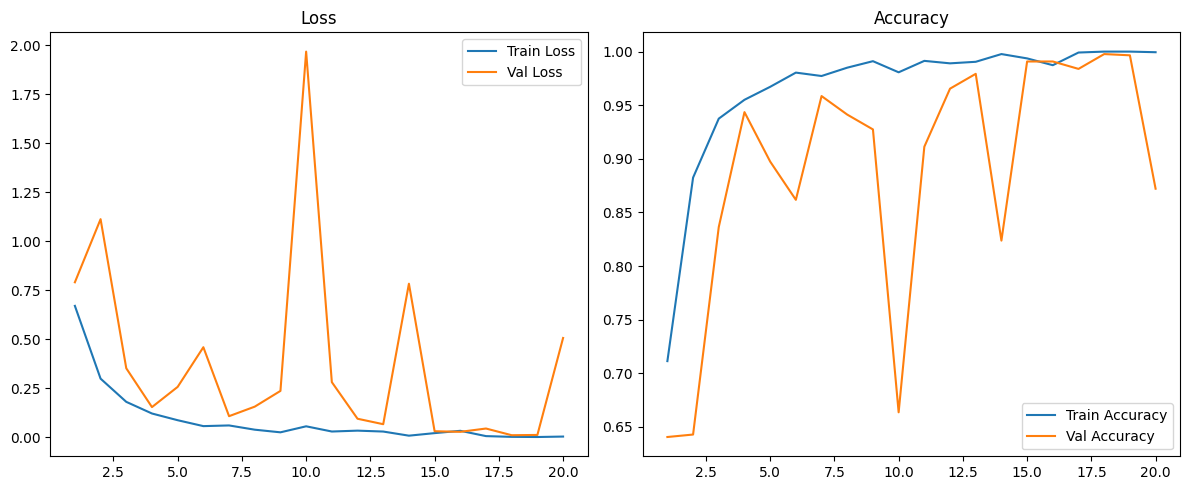

Model saved as RaghadAlamoudi_ucf11_model.h5
Timestamp: 2026_04_22__01_18_18


In [ ]:


validate_chosen_classes(dataset_directory, chosen_classes)

features, labels = create_dataset(
    dataset_root=dataset_directory,
    class_names=chosen_classes,
    target_size=(image_width, image_height),
    num_samples_per_video=frames_per_video,
    max_videos_each_class=max_videos_per_class,
)

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

show_random_samples(features, labels, chosen_classes, num_samples=9)

one_hot_labels = to_categorical(labels, num_classes=len(chosen_classes))

x_train, x_test, y_train, y_test = train_test_split(
    features,
    one_hot_labels,
    test_size=test_size,
    shuffle=True,
    stratify=labels,
    random_state=random_seed,
)

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}, y_test:  {y_test.shape}")

model = build_model(
    input_shape=(image_height, image_width, channels),
    num_classes=len(chosen_classes),
)

model.summary()

plot_model(
    model,
    to_file="ucf11_model_structure.png",
    show_shapes=True,
    show_layer_names=True,
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1,
)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

plot_training_history(history)

timestamp = dt.datetime.now().strftime("%Y_%m_%d__%H_%M_%S")
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")
print(f"Timestamp: {timestamp}")

# External Youtube Validation

In [ ]:

external_videos = [
    "/Users/raghadhome/Downloads/basket ball.mp4",
    "/Users/raghadhome/Downloads/bike.mp4",
    "/Users/raghadhome/Downloads/bike.mp4",
]

validate_external_videos(
    model=model,
    class_names=chosen_classes,
    external_video_paths=external_videos,
    target_size=(image_width, image_height),
    num_samples=20,
)


External Video Validation
--------------------------------------------------
Video: /Users/raghadhome/Downloads/basket ball.mp4
Predicted class: basketball
Confidence: 0.4831
Class probabilities:
  basketball           0.4831
  biking               0.4310
  tennis_swing         0.0859
--------------------------------------------------
Video: /Users/raghadhome/Downloads/bike.mp4
Predicted class: biking
Confidence: 0.9138
Class probabilities:
  basketball           0.0836
  biking               0.9138
  tennis_swing         0.0026
--------------------------------------------------
Video: /Users/raghadhome/Downloads/bike.mp4
Predicted class: biking
Confidence: 0.9138
Class probabilities:
  basketball           0.0836
  biking               0.9138
  tennis_swing         0.0026
--------------------------------------------------
